In [72]:
import yaml

with open("../config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)

In [ ]:
import json
import heapq
import os
import cv2
import numpy as np
import random
import shutil
import pandas as pd
from tqdm import tqdm
from PIL import Image
from scipy.stats import gaussian_kde
import pickle
from IPython import get_ipython
from IPython.display import display
from pycocotools.coco import COCO
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid
import torchvision.transforms as T
import albumentations as A
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

 ### Data Preparation: Extraction of Document Elements from COCO Dataset

This section details the process of extracting individual document elements from a combined dataset
 formatted in the Common Objects in Context (COCO) annotation style. The goal is to isolate
 each annotated region as a separate image file, categorized by its class label (e.g., headline, article).
These extracted elements form the basis for generating synthetic document layouts.

In [4]:
annotations_path = CONFIG["annotations_path"] # Path to the input COCO annotation file
images_path = CONFIG["images_path"] # Path to the directory containing original images
elements_path = CONFIG["elements_path"] # Output directory for extracted elements

# initialize COCO object with the path to the annotation file
coco = COCO(annotations_path)

# Define the class names for element extraction. These names correspond to the 'name' field in the COCO categories
label_names = CONFIG["label_names"]

# output directories for each element class
for label in label_names:
    os.makedirs(os.path.join(elements_path, label), exist_ok=True)

# extract and save elements.
for annotation in coco.loadAnns(coco.getAnnIds()):
    image_id = annotation['image_id'] 
    bbox = annotation['bbox']  # [x, y, width, height] 
    category_id = annotation['category_id']
    category_name = coco.loadCats(category_id)[0]['name']

    # load image information
    image_info = coco.loadImgs(image_id)[0]
    # Construct full path to the image file
    image_file = os.path.join(images_path, image_info['file_name'])

    try:
        image = Image.open(image_file).convert("RGB")
    except FileNotFoundError:
        print(f"image file not found at {image_file}. annotation {annotation['id']}.")
        continue
    except Exception as e:
        print(f"error opening or processing image {image_file}: {e}. annotation {annotation['id']}.")
        continue

    # floating-point bounding box coordinates to integers for cropping image 
    x, y, width, height = map(int, bbox)

    # check bounding box coordinates are within bounds
    img_width, img_height = image.size
    x = max(0, x)
    y = max(0, y)
    width = min(width, img_width - x)
    height = min(height, img_height - y)

    if width <= 0 or height <= 0:
        print(f"invalid bounding box dimensions for annotation {annotation['id']}")
        continue
        
    cropped_element = image.crop((x, y, x + width, y + height))

    # filename includes category name, image ID, and annotation ID
    element_filename = f"{category_name}_{image_id}_{annotation['id']}.png"
    save_path = os.path.join(elements_path, category_name, element_filename)

    try:
        cropped_element.save(save_path)
    except Exception as e:
        print(f"Warning: Error saving element {element_filename} to {save_path}: {e}. Skipping.")
        continue


print("Element extraction complete.")

loading annotations into memory...
Done (t=-0.82s)
creating index...
index created!
Element extraction complete.


In [6]:
from torchvision.utils import make_grid
import torchvision.transforms as T
import torch

def load_images(class_dir, sample_size=20):
    files = os.listdir(class_dir)
    imgs = []
    for f in files[:sample_size]:
        path = os.path.join(class_dir, f)
        try:
            img = Image.open(path).convert('RGB')
            img = T.Resize((128, 128))(img)
            imgs.append(T.ToTensor()(img))
        except:
            # Skip corrupt or unreadable files
            continue
    return imgs

# Iterate through each class directory
for cls in os.listdir(elements_path):
    # Skip hidden files
    if cls.startswith('.') or 'checkpoint' in cls.lower():
        continue
    else:
        imgs = load_images(os.path.join(elements_path, cls))
        print(os.path.join(elements_path, cls))
        # grid of the loaded images
        grid = make_grid(torch.stack(imgs), nrow=5)
        # convert the grid to a PIL Image and save
        T.ToPILImage()(grid).save(f'plots_{cls}.jpg')

../data/processed/elements_merged/advertisement
../data/processed/elements_merged/article
../data/processed/elements_merged/headline
../data/processed/elements_merged/subheading


In [7]:
def process_element_directories(dirs):
    all_data = []
    for d in dirs:
        if not os.path.isdir(d):
            print(f"directory not found: {d}.")
            continue

        for cls in os.listdir(d):
            cls_path = os.path.join(d, cls)
            if cls.startswith('.') or 'checkpoint' in cls.lower() or not os.path.isdir(cls_path):
                 continue
            
            for f in os.listdir(cls_path):
                fpath = os.path.join(cls_path, f)
                if not fpath.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                
                try:
                    with Image.open(fpath) as im:
                        w, h = im.size
                        aspect_ratio = round(w / h, 2) if h > 0 else 0
                        area = w * h
                        all_data.append({
                            'class': cls,
                            'filename': f,
                            'width': w,
                            'height': h,
                            'aspect_ratio': aspect_ratio,
                            'area': area,
                            'source': 'augmented' if 'aug' in f else 'real'
                        })
                except Exception as e:
                    # Print a warning for files that could not be processed
                    print(f" Could not process file {fpath}: {e}.")
                    continue

    df = pd.DataFrame(all_data)
    return df

In [9]:
df = process_element_directories([elements_path])
print(df.head())

           class                filename  width  height  aspect_ratio    area  \
0  advertisement     advertisement04.png    320     108          2.96   34560   
1  advertisement  advertisement17139.png    242     822          0.29  198924   
2  advertisement  advertisement22198.png    443     691          0.64  306113   
3  advertisement    advertisement222.png    235     199          1.18   46765   
4  advertisement    advertisement232.png    357     530          0.67  189210   

  source  
0   real  
1   real  
2   real  
3   real  
4   real  


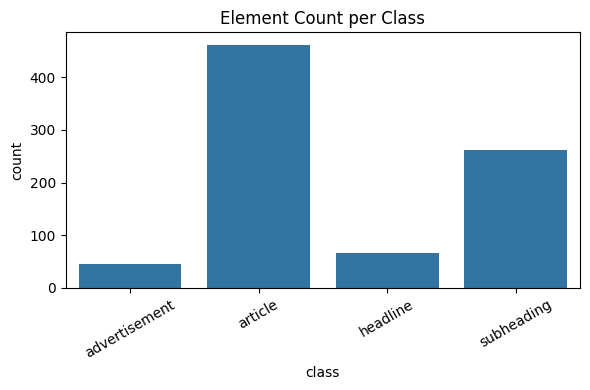

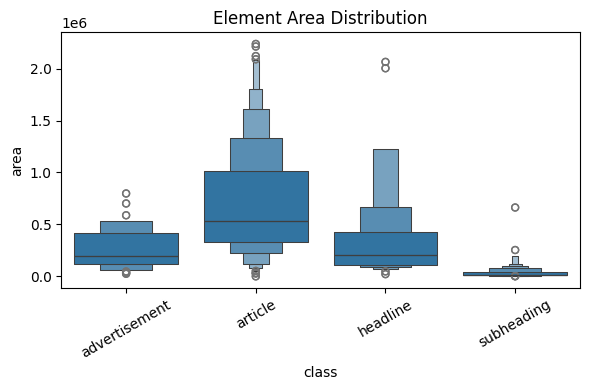

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class')
plt.title('Element Count per Class')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# element area   
plt.figure(figsize=(6, 4))
sns.boxenplot(data=df, x='class', y='area')
plt.title('Element Area Distribution')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Data Augmentation for Rare Classes
This cell applies data augmentation techniques to elements belonging to the identified "rare" classes. Using the `albumentations` library, transforms including random brightness and contrast, rotation, elastic transformation, and Gaussian blur are applied to generate additional synthetic examples for these classes.

In [11]:
rare_classes = df['class'].value_counts()[df['class'].value_counts() < 100]

In [13]:
import albumentations as A
import cv2
import os
import pandas as pd

# transforms are applied sequentially
augment = A.Compose([
    A.RandomBrightnessContrast(p=0.5), #  adjust brightness and contrast
    A.Rotate(limit=2, p=0.5),          #  rotate the image by a small degree
    A.ElasticTransform(alpha=1, sigma=50, p=0.3), # elastic transformations
    A.GaussianBlur(p=0.2),             # Gaussian blur
])

# output dir
aug_out_dir = CONFIG["aug_out_dir"]

for cls in rare_classes.index:
    os.makedirs(os.path.join(aug_out_dir, cls), exist_ok=True)
    imgs = os.listdir(os.path.join(elements_path, cls))

    for fname in imgs:
        img_path = os.path.join(elements_path, cls, fname)
        # Images are read as BGR by default.
        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Could not read image {img_path}. Skipping.")
            continue

        for i in range(3):  # 3 variants per original image
            # returns a dict
            augmented = augment(image=image)['image']
            # filename is prefixed with 'aug<i>' to indicate it's an augmented version
            # saveed image in BGR format
            try:
                cv2.imwrite(os.path.join(aug_out_dir, cls, f'aug{i}_{fname}'), augmented)
            except Exception as e:
                print(f"error saving augmented image {f'aug{i}_{fname}'} to {os.path.join(aug_out_dir, cls)}: {e}.")
                continue

##  Real vs Augmented Element Statistics
This cell consolidates the statistics (width, height, aspect ratio, area) of both the original ("real") and augmented document elements into a single DataFrame. This combined dataset helps to analyze the impact of augmentation and for following steps that require a comprehensive pool of elements.


In [16]:
df_aug = process_element_directories([elements_path, aug_out_dir])
print(df.head())

           class                filename  width  height  aspect_ratio    area  \
0  advertisement     advertisement04.png    320     108          2.96   34560   
1  advertisement  advertisement17139.png    242     822          0.29  198924   
2  advertisement  advertisement22198.png    443     691          0.64  306113   
3  advertisement    advertisement222.png    235     199          1.18   46765   
4  advertisement    advertisement232.png    357     530          0.67  189210   

  source  
0   real  
1   real  
2   real  
3   real  
4   real  


### Visualize Class and Aspect Ratio Distribution of Real and Augmented Elements
This cell generates a count plot visualizing the distribution of document elements per class, differentiated by their source (real or augmented).


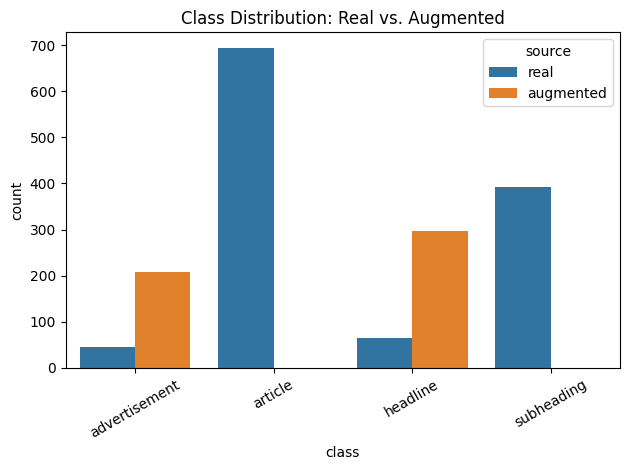

In [17]:
sns.countplot(data=df_aug, x='class', hue='source')
plt.title("Class Distribution: Real vs. Augmented")
plt.xticks(rotation=30)
plt.tight_layout()

(0.0, 30.0)

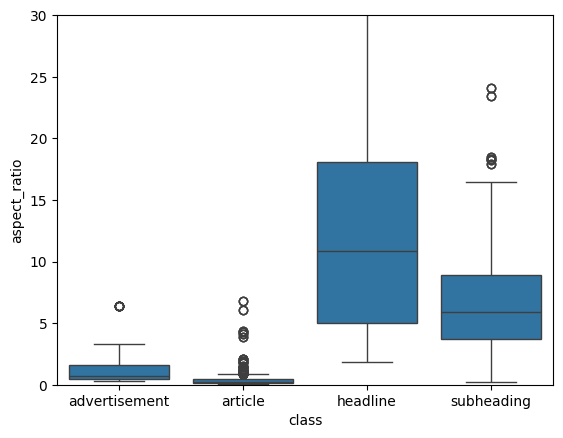

In [20]:
sns.boxplot(data=df_aug, x='class', y='aspect_ratio')
plt.ylim(0, 30)

## Train and Save the Kernel Density Estimation Model
This cell trains Kernel Density Estimation (KDE) models for the statistical distributions of key document element properties (width, height, aspect ratio, and area) for each class, using the combined real and augmented element data. KDE models provide a non-parametric way to estimate the probability density function of these properties. The trained KDE models are then serialized and saved to a pickle file.


In [21]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from scipy.stats import gaussian_kde
import pickle
 
records = []
for cls in label_names:
    class_dir = os.path.join(aug_out_dir, cls)
    if not os.path.exists(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        fpath = os.path.join(class_dir, fname)
        try:
            with Image.open(fpath) as im:
                w, h = im.size
                ar = w / h if h > 0 else 0
                area = w * h
                records.append({
                    "class": cls,
                    "width": w,
                    "height": h,
                    "aspect_ratio": ar,
                    "area": area,
                    "path": fpath
                })
        except:
            continue

df = pd.DataFrame(records)

# dictionary to store KDE models for each property and class
kde_models = {}

# Train a Gaussian KDE
for cls in label_names:
    cls_data = df[df["class"] == cls]
    if cls_data.empty:
        continue
    # Train KDE for each relevant property
    kde_models[cls] = {
        "width": gaussian_kde(cls_data["width"]),
        "height": gaussian_kde(cls_data["height"]),
        "aspect_ratio": gaussian_kde(cls_data["aspect_ratio"]),
        "area": gaussian_kde(cls_data["area"])
    }

# save pkl file
with open(CONFIG["layout_model"], "wb") as f:
    pickle.dump(kde_models, f)

model_summary = {
    cls: list(stats.keys()) for cls, stats in kde_models.items()
}
model_summary
 


{'headline': ['width', 'height', 'aspect_ratio', 'area'],
 'subheading': ['width', 'height', 'aspect_ratio', 'area'],
 'article': ['width', 'height', 'aspect_ratio', 'area'],
 'advertisement': ['width', 'height', 'aspect_ratio', 'area']}

## Synthetic Document Layout Generation (Rule-Based with Element Placement)

This cell implements a rule-based approach for generating synthetic document page layouts and their corresponding annotations. The process constructs pages by placing pre-extracted document elements (from the augmented pool).

1.  **Configuration and Initialization**
2.  **Page Generation Loop:** For each page:
    *   A blank white grayscale image is created.
    *   **Headline Placement:** A headline element is selected randomly, resized to fit the page width, and placed at the top.
    *   **Column Structure:** The remaining page area is divided into a random number of vertical columns with defined margins.
    *   **Column Content Placement:** For each column, elements (optional subheading, mandatory article, optional advertisement) are selected using an aspect ratio fitting heuristic with a usage penalty, resized, and placed within the column based on defined vertical flow and horizontal centering.
    *   **Annotation:** Bounding boxes are calculated and stored in YOLO and COCO formats.

The element selection is now based on a custom function (`select_best_fit_element`) that tries to find an element whose aspect ratio closely matches the target aspect ratio dictated by the available space (column width and remaining height) and then penalizes elements that have been used frequently.

In [29]:
# Helper
def normalize_bbox(x, y, w, h, pw, ph):
    return [(x + w / 2) / pw, (y + h / 2) / ph, w / pw, h / ph]

def resize_to_fit(img, target_w, target_h):
    h, w = img.shape[:2]
    scale = min(target_w / w, target_h / h)
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)


In [ ]:
from collections import defaultdict

# --- CONFIG ---
OUTPUT_DIR = CONFIG["synthetic_datasets"]["final"] # root output dir
IMG_DIR = os.path.join(OUTPUT_DIR, 'images') # Dir for images
LBL_DIR = os.path.join(OUTPUT_DIR, 'labels') # Dir for YOLO annotation 
ANN_DIR = os.path.join(OUTPUT_DIR, 'annotations') # Dir for COCO annotation 
PAGE_WIDTH = 1700  
PAGE_HEIGHT = 1900 
NUM_PAGES = 1500 # number of pages to generate
CLASS_TO_ID = {cls: i for i, cls in enumerate(label_names)} # 0-indexed mapping ( class name string to integer ID )
ELEMENT_DIR = aug_out_dir
COLUMN_MARGIN = 8 # Hor margin between adjacent cols
TOP_MARGIN = 30 # Ver margin (above headline)
BOTTOM_MARGIN = 20 # Ver margin - bottom

# --- Init ---
# output dirs
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(LBL_DIR, exist_ok=True)
os.makedirs(ANN_DIR, exist_ok=True)

# Reload element paths
element_pool = {cls: [] for cls in label_names}
for cls in label_names:
    cls_dir = os.path.join(ELEMENT_DIR, cls)
    if not os.path.exists(cls_dir): continue
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            element_pool[cls].append(os.path.join(cls_dir, fname))

# base COCO annotation structure
# IDs start from 1
coco = {
    "images": [],
    "annotations": [], # bounding box and category annotations
    "categories": [{"id": i, "name": name} for i, name in enumerate(label_names)]
}

ann_id = 1 # counter for unique annotation IDs

element_usage = {cls: defaultdict(int) for cls in label_names}

for cls in label_names:
    for path in element_pool.get(cls, []):
        element_usage[cls][path] = 0  # Start with 0 usage count

def select_best_fit_element(cls, target_ar, tolerance=0.3, lambda_penalty=0.15):
    candidates = []
    for path in element_pool.get(cls, []):
        if not os.path.exists(path): continue
        # Reading as grayscale matches the output page format
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, w = img.shape[:2] # Get original height and width
        if h == 0: continue
        ar = w / h
        ar_dist = abs(ar - target_ar) # Check if the element's aspect ratio is within the defined tolerance of the target AR
        if ar_dist < tolerance:
            usage_count = element_usage[cls].get(path, 0) # Get the current usage count for this element path.
            # Calc selection score: aspect ratio distance + weighted usage penalty
            # lower score indicates a better candidate.
            score = ar_dist + lambda_penalty * usage_count
            candidates.append((score, path))

    if not candidates:
        return None

    # Select the candidate with the best combined score
    best_path = sorted(candidates, key=lambda x: x[0])[0][1]

    # Increment the usage count for the selected element
    element_usage[cls][best_path] += 1
    return best_path


# main
for idx in tqdm(range(NUM_PAGES)):
    page = np.ones((PAGE_HEIGHT, PAGE_WIDTH), dtype=np.uint8) * 255
    labels = []
    y_cursor = TOP_MARGIN  # track of the current vertical position

    # Headline
    headline_paths = element_pool.get('headline', [])
    headline_path = random.choice(headline_paths) if headline_paths else None

    if headline_path:
        element_usage['headline'][headline_path] += 1
        img = cv2.imread(headline_path, cv2.IMREAD_GRAYSCALE)
        if img.shape[1] > PAGE_WIDTH:
            img = resize_to_fit(img, PAGE_WIDTH, 200)
            h, w = img.shape[:2]
            x_pos = (PAGE_WIDTH - w) // 2
            y_end = y_cursor + h

            if y_end < PAGE_HEIGHT - BOTTOM_MARGIN and x_pos + w <= PAGE_WIDTH:
                page[y_cursor:y_end, x_pos:x_pos + w] = img

                norm = normalize_bbox(x_pos, y_cursor, w, h, PAGE_WIDTH, PAGE_HEIGHT)
                labels.append(f"{CLASS_TO_ID['headline']} " + " ".join(f"{v:.6f}" for v in norm))
                coco['annotations'].append({
                    "id": ann_id,
                    "image_id": idx,
                    "category_id": CLASS_TO_ID['headline'],
                    "bbox": [x_pos, y_cursor, w, h],
                    "area": w * h,
                    "iscrowd": 0
                })
                ann_id += 1
                y_cursor = y_end + 10
            else:
                print(f"[WARN] Page {idx}: Headline too tall. Skipping.")
    else:
        print(f"[WARN] Page {idx}: No headline available")


    #  Columns (Subheading, Article, Ad)
    num_cols = random.randint(2, 7)
    col_width = (PAGE_WIDTH - (num_cols - 1) * COLUMN_MARGIN) // num_cols
    x_positions = [i * (col_width + COLUMN_MARGIN) for i in range(num_cols)] # starting x-position for each column.
    available_height = PAGE_HEIGHT - y_cursor - BOTTOM_MARGIN - 100  # space remaining below the y_cursor (after the headline) & above the bottom margin

    for x0 in x_positions:
        # vertical cursor for placement *within* the current column
        col_y = y_cursor

        # Subh
        if random.random() < 0.8:   # 80% chance of attempting to place a subheading
            sh_path = select_best_fit_element('subheading', target_ar=col_width / 60)
            if sh_path:
                img = cv2.imread(sh_path, cv2.IMREAD_GRAYSCALE)
                img_resized = resize_to_fit(img, col_width, 80)
                h, w = img_resized.shape[:2]
                x_pos = x0 + (col_width - w) // 2
                page[col_y:col_y + h, x_pos:x_pos + w] = img_resized
                norm = normalize_bbox(x_pos, col_y, w, h, PAGE_WIDTH, PAGE_HEIGHT)
                labels.append(f"{CLASS_TO_ID['subheading']} " + " ".join(f"{v:.6f}" for v in norm))
                coco['annotations'].append({
                    "id": ann_id,
                    "image_id": idx,
                    "category_id": CLASS_TO_ID['subheading'],
                    "bbox": [x_pos, col_y, w, h],
                    "area": w * h,
                    "iscrowd": 0
                })
                ann_id += 1
                col_y += h + 5

        # Article
        # calc the remaining available vertical height
        art_path = select_best_fit_element('article', target_ar=col_width / available_height)
        if art_path:
            img = cv2.imread(art_path, cv2.IMREAD_GRAYSCALE)
            img_resized = resize_to_fit(img, col_width, available_height)
            h, w = img_resized.shape[:2]
            x_pos = x0 + (col_width - w) // 2
            page[col_y:col_y + h, x_pos:x_pos + w] = img_resized
            norm = normalize_bbox(x_pos, col_y, w, h, PAGE_WIDTH, PAGE_HEIGHT)
            labels.append(f"{CLASS_TO_ID['article']} " + " ".join(f"{v:.6f}" for v in norm))
            coco['annotations'].append({
                "id": ann_id,
                "image_id": idx,
                "category_id": CLASS_TO_ID['article'],
                "bbox": [x_pos, col_y, w, h],
                "area": w * h,
                "iscrowd": 0
            })
            ann_id += 1

        # ad
        if random.random() < 0.9:
            ad_path = select_best_fit_element('advertisement', target_ar=col_width / 60)
            if ad_path:
                img = cv2.imread(ad_path, cv2.IMREAD_GRAYSCALE)
                img_resized = resize_to_fit(img, col_width, 100)
                h, w = img_resized.shape[:2]
                x_pos = x0 + (col_width - w) // 2
                y_pos = PAGE_HEIGHT - h - BOTTOM_MARGIN
                page[y_pos:y_pos + h, x_pos:x_pos + w] = img_resized
                norm = normalize_bbox(x_pos, y_pos, w, h, PAGE_WIDTH, PAGE_HEIGHT)
                labels.append(f"{CLASS_TO_ID['advertisement']} " + " ".join(f"{v:.6f}" for v in norm))
                coco['annotations'].append({
                    "id": ann_id,
                    "image_id": idx,
                    "category_id": CLASS_TO_ID['advertisement'],
                    "bbox": [x_pos, y_pos, w, h],
                    "area": w * h,
                    "iscrowd": 0
                })
                ann_id += 1

    img_filename = f"page_{idx:05d}.jpg"
    lbl_filename = f"page_{idx:05d}.txt"

    cv2.imwrite(os.path.join(IMG_DIR, img_filename), page)
    with open(os.path.join(LBL_DIR, lbl_filename), 'w') as f:
        f.write("\n".join(labels))

    coco['images'].append({
        "id": idx,
        "file_name": img_filename,
        "width": PAGE_WIDTH,
        "height": PAGE_HEIGHT
    })

with open(os.path.join(ANN_DIR, "coco.json"), "w") as f:
    json.dump(coco, f, indent=2)

{
    "pages_generated": NUM_PAGES,
    "output_structure": "grayscale pages with 1 headline, 1 article per column + subheading/advertisement",
    "layout_type": "best fit layout",
    "output_paths": {
        "images": IMG_DIR,
        "yolo": LBL_DIR,
        "coco": os.path.join(ANN_DIR, "coco.json")
    }
}

## Split Dataset into Training & Validation Sets

In [117]:
import os
import random
import shutil

IMAGE_DIR = CONFIG['image_dir']
LABEL_DIR = CONFIG['labels_dir']
TRAIN_RATIO = 0.8
SEED = 42  # reproducibility

OUT_DIRS = {
    'train_images': os.path.join(IMAGE_DIR, 'train', 'images'),
    'train_labels': os.path.join(LABEL_DIR, 'train', 'labels'),
    'val_images': os.path.join(IMAGE_DIR, 'val', 'images'),
    'val_labels': os.path.join(LABEL_DIR, 'val', 'labels')
}

for d in OUT_DIRS.values():
    os.makedirs(d, exist_ok=True)

image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
image_files.sort()
random.seed(SEED)
random.shuffle(image_files)

split_idx = int(len(image_files) * TRAIN_RATIO)
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

def move_files(file_list, subset):
    for img_file in file_list:
        label_file = os.path.splitext(img_file)[0] + '.txt'

        src_img_path = os.path.join(IMAGE_DIR, img_file)
        src_label_path = os.path.join(LABEL_DIR, label_file)

        dst_img_path = os.path.join(OUT_DIRS[f'{subset}_images'], img_file)
        dst_label_path = os.path.join(OUT_DIRS[f'{subset}_labels'], label_file)

        shutil.copy2(src_img_path, dst_img_path)
        if os.path.exists(src_label_path):
            shutil.copy2(src_label_path, dst_label_path)
        else:
            print(f'no label file for {img_file}')

move_files(train_files, 'train')
move_files(val_files, 'val')

print(f'Done')

Done


In [1]:
import torch

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
